In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

folder_path = '/content/drive/MyDrive/grayscale_images'  # Replace with the actual path

try:
    all_files = os.listdir(folder_path)
    image_files = [f for f in all_files if os.path.isfile(os.path.join(folder_path, f)) and f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print("Image files found:")
    for img_file in image_files:
        print(img_file)
except FileNotFoundError:
    print(f"Error: The folder '{folder_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")


Image files found:
071.jpg
033.jpg
081.jpg
028.jpg
106.jpg
117.jpg
074.jpg
036.jpg
105.jpg
1.jpg
048.jpg
128.jpg
099.jpg
062.jpg
092.jpg
025.jpg
119.jpg
090.jpg
019.jpg
075.jpg
104.jpg
018.jpg
085.jpg
050.jpg
084.jpg
098.jpg
064.jpg
145.jpg
068.jpg
053.jpg
042.jpg
110.jpg
070.jpg
3.jpg
067.jpg
120.jpg
086.jpg
127.jpg
112.jpg
155.jpg
139.jpg
163.jpg
107.jpg
057.jpg
069.jpg
115.jpg
039.jpg
014.jpg
124.jpg
026.jpg
076.jpg
073.jpg
072.jpg
046.jpg
034.jpg
016.jpg
017.jpg
108.jpg
123.jpg
079.jpg
030.jpg
065.jpg
032.jpg
061.jpg
021.jpg
005.jpg
045.jpg
077.jpg
126.jpg
141.jpg
5.jpg
130.jpg
100.jpg
149.jpg
015.jpg
043.jpg
007.jpg
148.jpg
153.jpg
133.jpg
113.jpg
131.jpg
024.jpg
003.jpg
004.jpg
091.jpg
044.jpg
138.jpg
101.jpg
040.jpg
135.jpg
066.jpg
102.jpg
157.jpg
137.jpg
116.jpg
035.jpg
134.jpg
118.jpg
173.jpg
2.jpg
013.jpg
082.jpg
055.jpg
121.jpg
001.jpg
103.jpg
010.jpg
095.jpg
049.jpg
022.jpg
027.jpg
051.jpg
093.jpg
031.jpg
089.jpg
111.jpg
159.jpg
008.jpg
096.jpg
023.jpg
012.jpg
002.jpg
054.j

In [3]:
import cv2
import numpy as np
import os

output_folder = '/content/drive/MyDrive/processed_images'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

for img_file in image_files:
    img_path = os.path.join(folder_path, img_file)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is not None:
        # Canny edge detection
        canny_edges = cv2.Canny(img, 100, 200) # Using common thresholds

        # Sobel edge detection
        sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=5)
        sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=5)
        sobel_edges = np.sqrt(sobelx**2 + sobely**2)
        sobel_edges = np.uint8(255 * sobel_edges / np.max(sobel_edges)) # Normalize to 0-255

        # Save results
        base_name, ext = os.path.splitext(img_file)
        canny_output_path = os.path.join(output_folder, f"{base_name}_canny.jpg")
        sobel_output_path = os.path.join(output_folder, f"{base_name}_sobel.jpg")

        cv2.imwrite(canny_output_path, canny_edges)
        cv2.imwrite(sobel_output_path, sobel_edges)
    else:
        print(f"Warning: Could not load image {img_file}")

print("Edge detection and saving complete.")

Edge detection and saving complete.


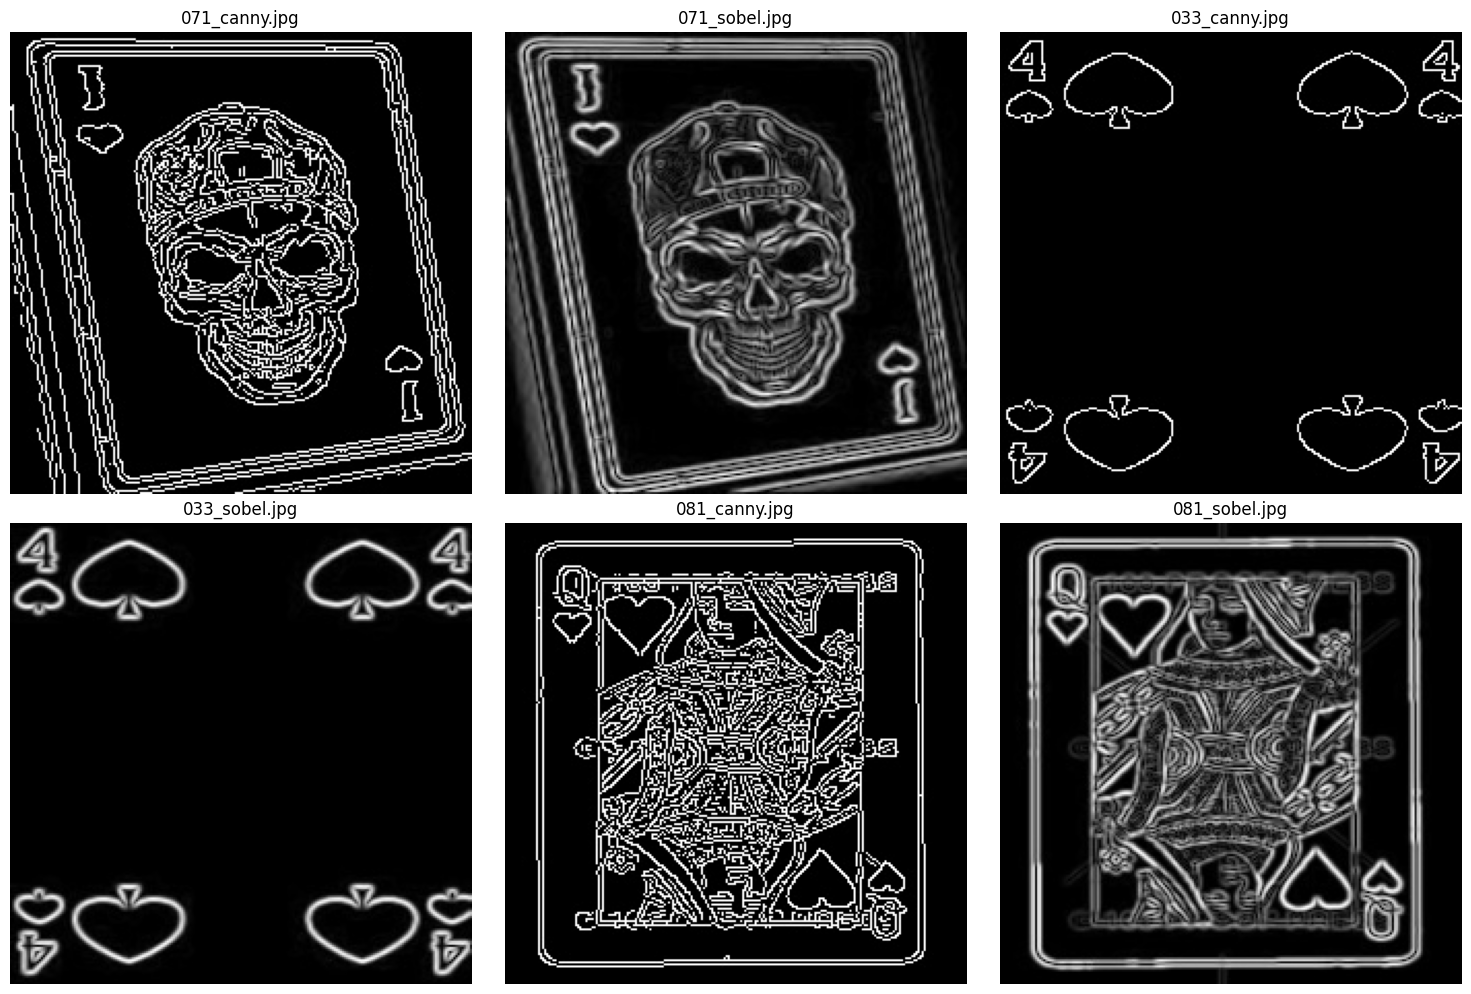

In [4]:
import matplotlib.pyplot as plt

# Select a few processed image filenames from the output_folder
processed_image_files = [f for f in os.listdir(output_folder) if os.path.isfile(os.path.join(output_folder, f))]
selected_files = processed_image_files[:6] # Select the first 6 files

plt.figure(figsize=(15, 10)) # Adjust figure size based on the number of images

for i, filename in enumerate(selected_files):
    filepath = os.path.join(output_folder, filename)
    img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE) # Read as grayscale

    plt.subplot(2, 3, i + 1) # Create a 2x3 grid for 6 images
    plt.imshow(img, cmap='gray')
    plt.title(filename)
    plt.axis('off') # Hide axes

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

In [5]:
# Continue from the previous loop to add dilation and erosion
for img_file in image_files:
    img_path = os.path.join(folder_path, img_file)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is not None:
        # Canny edge detection (already done in the previous cell, but keeping here for completeness of the loop)
        canny_edges = cv2.Canny(img, 100, 200)

        # Sobel edge detection (already done in the previous cell, but keeping here for completeness of the loop)
        sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=5)
        sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=5)
        sobel_edges = np.sqrt(sobelx**2 + sobely**2)
        sobel_edges = np.uint8(255 * sobel_edges / np.max(sobel_edges))

        # Define kernel for morphological operations
        kernel = np.ones((5,5),np.uint8)

        # Apply dilation
        dilation = cv2.dilate(img, kernel, iterations = 1)

        # Apply erosion
        erosion = cv2.erode(img, kernel, iterations = 1)

        # Save results
        base_name, ext = os.path.splitext(img_file)

        canny_output_path = os.path.join(output_folder, f"{base_name}_canny.jpg")
        sobel_output_path = os.path.join(output_folder, f"{base_name}_sobel.jpg")
        dilation_output_path = os.path.join(output_folder, f"{base_name}_dilation.jpg")
        erosion_output_path = os.path.join(output_folder, f"{base_name}_erosion.jpg")

        cv2.imwrite(canny_output_path, canny_edges)
        cv2.imwrite(sobel_output_path, sobel_edges)
        cv2.imwrite(dilation_output_path, dilation)
        cv2.imwrite(erosion_output_path, erosion)

    else:
        print(f"Warning: Could not load image {img_file}")

print("Edge detection and morphological operations and saving complete.")

Edge detection and morphological operations and saving complete.


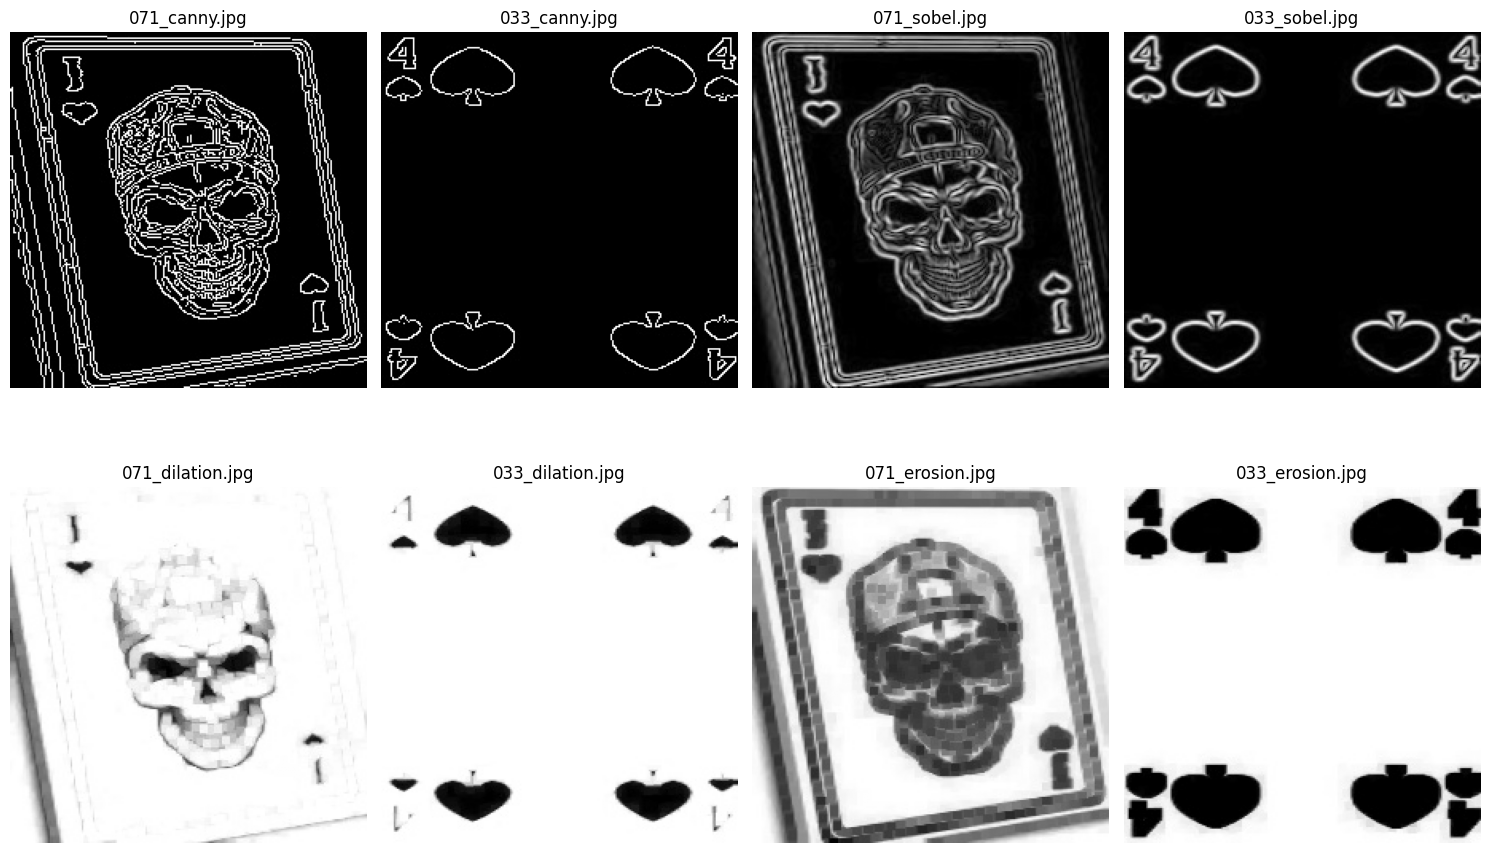

In [6]:
processed_image_files = [f for f in os.listdir(output_folder) if os.path.isfile(os.path.join(output_folder, f))]

# Filter for specific processed types
filtered_files = [f for f in processed_image_files if "_canny.jpg" in f or "_sobel.jpg" in f or "_dilation.jpg" in f or "_erosion.jpg" in f]

# Select a few representative files (adjust as needed)
selected_files = []
canny_files = [f for f in filtered_files if "_canny.jpg" in f][:2]
sobel_files = [f for f in filtered_files if "_sobel.jpg" in f][:2]
dilation_files = [f for f in filtered_files if "_dilation.jpg" in f][:2]
erosion_files = [f for f in filtered_files if "_erosion.jpg" in f][:2]

selected_files.extend(canny_files)
selected_files.extend(sobel_files)
selected_files.extend(dilation_files)
selected_files.extend(erosion_files)

plt.figure(figsize=(15, 10)) # Adjust figure size based on the number of images

for i, filename in enumerate(selected_files):
    filepath = os.path.join(output_folder, filename)
    img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE) # Read as grayscale

    if img is not None:
        plt.subplot(len(selected_files)//4 + (len(selected_files)%4>0), 4, i + 1) # Create subplots dynamically
        plt.imshow(img, cmap='gray')
        plt.title(filename)
        plt.axis('off') # Hide axes
    else:
        print(f"Warning: Could not load image {filename} for display.")


plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

In [7]:
folder_path = '/content/drive/MyDrive/grayscale_images' # Replace with the actual path

try:
    all_files = os.listdir(folder_path)
    image_files = [f for f in all_files if os.path.isfile(os.path.join(folder_path, f)) and f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print("Image files found:")
    for img_file in image_files:
        print(img_file)
except FileNotFoundError:
    print(f"Error: The folder '{folder_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Image files found:
071.jpg
033.jpg
081.jpg
028.jpg
106.jpg
117.jpg
074.jpg
036.jpg
105.jpg
1.jpg
048.jpg
128.jpg
099.jpg
062.jpg
092.jpg
025.jpg
119.jpg
090.jpg
019.jpg
075.jpg
104.jpg
018.jpg
085.jpg
050.jpg
084.jpg
098.jpg
064.jpg
145.jpg
068.jpg
053.jpg
042.jpg
110.jpg
070.jpg
3.jpg
067.jpg
120.jpg
086.jpg
127.jpg
112.jpg
155.jpg
139.jpg
163.jpg
107.jpg
057.jpg
069.jpg
115.jpg
039.jpg
014.jpg
124.jpg
026.jpg
076.jpg
073.jpg
072.jpg
046.jpg
034.jpg
016.jpg
017.jpg
108.jpg
123.jpg
079.jpg
030.jpg
065.jpg
032.jpg
061.jpg
021.jpg
005.jpg
045.jpg
077.jpg
126.jpg
141.jpg
5.jpg
130.jpg
100.jpg
149.jpg
015.jpg
043.jpg
007.jpg
148.jpg
153.jpg
133.jpg
113.jpg
131.jpg
024.jpg
003.jpg
004.jpg
091.jpg
044.jpg
138.jpg
101.jpg
040.jpg
135.jpg
066.jpg
102.jpg
157.jpg
137.jpg
116.jpg
035.jpg
134.jpg
118.jpg
173.jpg
2.jpg
013.jpg
082.jpg
055.jpg
121.jpg
001.jpg
103.jpg
010.jpg
095.jpg
049.jpg
022.jpg
027.jpg
051.jpg
093.jpg
031.jpg
089.jpg
111.jpg
159.jpg
008.jpg
096.jpg
023.jpg
012.jpg
002.jpg
054.j

In [8]:
dilation_output_folder = '/content/drive/MyDrive/dilation_images'
erosion_output_folder = '/content/drive/MyDrive/erosion_images'

if not os.path.exists(dilation_output_folder):
    os.makedirs(dilation_output_folder)
    print(f"Dilation output folder created at: {dilation_output_folder}")
else:
    print(f"Dilation output folder already exists at: {dilation_output_folder}")

if not os.path.exists(erosion_output_folder):
    os.makedirs(erosion_output_folder)
    print(f"Erosion output folder created at: {erosion_output_folder}")
else:
    print(f"Erosion output folder already exists at: {erosion_output_folder}")

Dilation output folder created at: /content/drive/MyDrive/dilation_images
Erosion output folder created at: /content/drive/MyDrive/erosion_images


In [9]:
for img_file in image_files:
    img_path = os.path.join(folder_path, img_file)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is not None:
        kernel = np.ones((5,5),np.uint8)
        dilation = cv2.dilate(img, kernel, iterations = 1)
        erosion = cv2.erode(img, kernel, iterations = 1)

        base_name, ext = os.path.splitext(img_file)
        dilation_output_path = os.path.join(dilation_output_folder, f"{base_name}_dilation.jpg")
        erosion_output_path = os.path.join(erosion_output_folder, f"{base_name}_erosion.jpg")

        cv2.imwrite(dilation_output_path, dilation)
        cv2.imwrite(erosion_output_path, erosion)
    else:
        print(f"Warning: Could not load image {img_file}")

print("Dilation, erosion, and saving complete.")

Dilation, erosion, and saving complete.


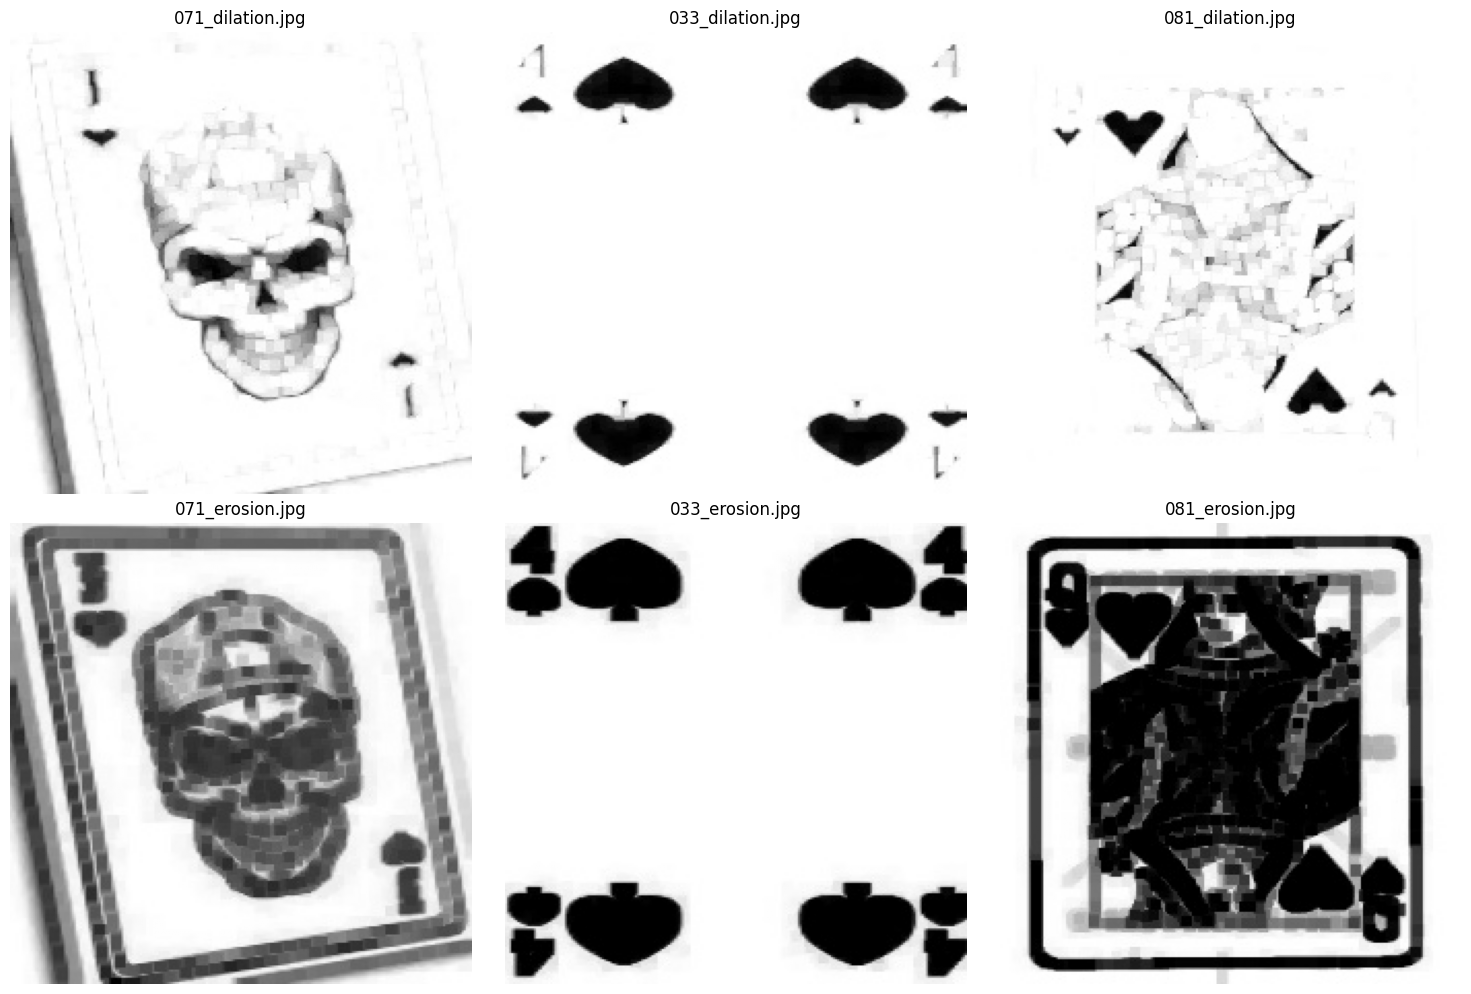

In [10]:
# Select a few image filenames from both output folders
dilation_files = [f for f in os.listdir(dilation_output_folder) if f.endswith('_dilation.jpg')][:3]
erosion_files = [f for f in os.listdir(erosion_output_folder) if f.endswith('_erosion.jpg')][:3]

selected_files = []
selected_files.extend(dilation_files)
selected_files.extend(erosion_files)

# Create a figure with subplots
plt.figure(figsize=(15, 10))

# Display the selected images
for i, filename in enumerate(selected_files):
    if "_dilation.jpg" in filename:
        filepath = os.path.join(dilation_output_folder, filename)
    elif "_erosion.jpg" in filename:
        filepath = os.path.join(erosion_output_folder, filename)
    else:
        continue # Skip files that don't match

    img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE) # Read as grayscale

    if img is not None:
        plt.subplot(2, 3, i + 1) # Create a 2x3 grid for 6 images
        plt.imshow(img, cmap='gray')
        plt.title(filename)
        plt.axis('off') # Hide axes
    else:
        print(f"Warning: Could not load image {filename} for display.")

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()